In [32]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Point FastF1 to your local cache folder
# This saves downloaded data locally so you don't redownload every run
fastf1.Cache.enable_cache('f1_cache')

print("FastF1 version:", fastf1.__version__)

FastF1 version: 3.8.1


# Monza 2024 Qualifying Analysis

In [33]:
# Load 2024 Monza Qualifying session
session = fastf1.get_session(2024, 'Monza', 'Q')
session.load()

# The laps are already a Pandas DataFrame
laps = session.laps

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']


In [34]:
print(laps.head())
print(laps.info())
print(laps.describe())
print("Shape:", laps.shape)
print("\nMissing values per column:")
print(laps.isnull().sum())

                    Time Driver DriverNumber                LapTime  \
0 0 days 00:16:12.142000    NOR            4                    NaT   
1 0 days 00:17:32.053000    NOR            4 0 days 00:01:19.911000   
2 0 days 00:19:23.074000    NOR            4 0 days 00:01:51.021000   
3 0 days 00:43:29.375000    NOR            4                    NaT   
4 0 days 00:44:49.102000    NOR            4 0 days 00:01:19.727000   

   LapNumber  Stint             PitOutTime              PitInTime  \
0        1.0    1.0 0 days 00:14:16.306000                    NaT   
1        2.0    1.0                    NaT                    NaT   
2        3.0    1.0                    NaT 0 days 00:19:18.770000   
3        4.0    2.0 0 days 00:41:40.139000                    NaT   
4        5.0    2.0                    NaT                    NaT   

             Sector1Time            Sector2Time  ... FreshTyre     Team  \
0                    NaT 0 days 00:00:37.116000  ...      True  McLaren   
1 0 days

In [35]:
# LapTime comes as a timedelta — convert to seconds for maths
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps['S1Seconds'] = laps['Sector1Time'].dt.total_seconds()
laps['S2Seconds'] = laps['Sector2Time'].dt.total_seconds()
laps['S3Seconds'] = laps['Sector3Time'].dt.total_seconds()

# Check missing values
print("Missing lap times:", laps['LapTimeSeconds'].isnull().sum())

# Drop rows with no lap time
laps = laps.dropna(subset=['LapTimeSeconds'])

# Some laps are outliers — in laps, pit laps, slow laps
# Keep only flying laps
laps = laps[laps['LapTimeSeconds'] > 60]    # remove impossibly short laps
laps = laps[laps['LapTimeSeconds'] < 200]   # remove very slow/aborted laps

laps = laps.reset_index(drop=True)

print("Clean laps remaining:", len(laps))

Missing lap times: 100
Clean laps remaining: 176


In [36]:
# Theoretical lap time from sector times
laps['TheoreticalBest'] = laps['S1Seconds'] + laps['S2Seconds'] + laps['S3Seconds']

# Gap to theoretical best — how much time is being lost
laps['GapToTheoretical'] = laps['LapTimeSeconds'] - laps['TheoreticalBest']

# Tyre age category
laps['TyreCategory'] = pd.cut(laps['TyreLife'],
                               bins=[0, 3, 8, 50],
                               labels=['New', 'Used', 'Old'])

# Flag personal best laps
laps['IsFastLap'] = (laps['LapTimeSeconds'] == 
                      laps.groupby('Driver')['LapTimeSeconds'].transform('min'))

print(laps[['Driver', 'LapTimeSeconds', 'TheoreticalBest', 
            'GapToTheoretical', 'TyreCategory']].head(10))

  Driver  LapTimeSeconds  TheoreticalBest  GapToTheoretical TyreCategory
0    NOR          79.911           79.911      0.000000e+00          New
1    NOR         111.021          111.021     -1.421085e-14          New
2    NOR          79.727           79.727      0.000000e+00          New
3    NOR         109.446          109.446      0.000000e+00          New
4    NOR          79.401           79.401      0.000000e+00          New
5    NOR         107.128          107.128      0.000000e+00          New
6    NOR          79.327           79.327      0.000000e+00          New
7    PIA         110.311          110.311      0.000000e+00          New
8    PIA          80.488           80.488      0.000000e+00          New
9    PIA         110.151          110.151     -1.421085e-14         Used


Techniques used:

- Arithmetic between columns to create TheoreticalBest — same as `power_w = voltage * current`
- `pd.cut()` — binning continuous tyre life into categories
- `groupby().transform('min')` — instead of collapsing to one row per group like normal groupby, transform returns a value for every row aligned to its group. So every VER row gets VER's minimum lap time, every HAM row gets HAM's minimum.

## Driver Performance Analysis

In [37]:
# Average lap time per driver — sorted fastest first
avg_laptimes = (laps.groupby('Driver')['LapTimeSeconds']
                    .mean()
                    .sort_values()
                    .reset_index())

avg_laptimes.columns = ['Driver', 'AvgLapTime']
print("=== Average Lap Time by Driver ===")
print(avg_laptimes.head(10))

# Best lap per driver
best_laps = (laps.groupby('Driver')['LapTimeSeconds']
                 .min()
                 .sort_values()
                 .reset_index())

print("\n=== Best Lap by Driver ===")
print(best_laps.head(10))

# Sector performance breakdown
sector_analysis = laps.groupby('Driver').agg({
    'S1Seconds': 'min',
    'S2Seconds': 'min',
    'S3Seconds': 'min',
    'LapTimeSeconds': 'min'
}).sort_values('LapTimeSeconds')

print("\n=== Best Sector Times by Driver ===")
print(sector_analysis.head(10).round(3))

=== Average Lap Time by Driver ===
  Driver  AvgLapTime
0    HUL   91.800818
1    ZHO   92.048833
2    ALB   92.236818
3    NOR   92.280143
4    RUS   93.570636
5    VER   94.046818
6    ALO   94.678714
7    PIA   95.166167
8    LEC   95.171929
9    HAM   95.354636

=== Best Lap by Driver ===
  Driver  LapTimeSeconds
0    NOR          79.327
1    PIA          79.436
2    RUS          79.440
3    LEC          79.461
4    SAI          79.467
5    HAM          79.513
6    VER          79.662
7    PER          80.062
8    ALB          80.299
9    HUL          80.339

=== Best Sector Times by Driver ===
        S1Seconds  S2Seconds  S3Seconds  LapTimeSeconds
Driver                                                 
NOR        26.395     26.579     26.253          79.327
PIA        26.399     26.643     26.386          79.436
RUS        26.296     26.836     26.300          79.440
LEC        26.373     26.732     26.356          79.461
SAI        26.223     26.823     26.421          79.467
HA

Techniques used:

- `groupby().mean()` : average per driver
- `groupby().min()` : personal best per driver
- `groupby().agg({})` : multiple different aggregations in one shot
- `sort_values()` : ranking drivers

##  Gap to Pole Analysis 

In [38]:
# Pole position time
pole_time = laps['LapTimeSeconds'].min()
pole_driver = laps.loc[laps['LapTimeSeconds'].idxmin(), 'Driver']

print(f"Pole: {pole_driver} — {pole_time:.3f}s")

# Gap to pole for every driver
gap_to_pole = (laps.groupby('Driver')['LapTimeSeconds']
                   .min()
                   .sort_values()
                   .reset_index())

gap_to_pole['GapToPole'] = gap_to_pole['LapTimeSeconds'] - pole_time
gap_to_pole.columns = ['Driver', 'BestLap', 'GapToPole']

print("\n=== Gap to Pole ===")
print(gap_to_pole.head(10).round(3))

# Sector mini-sectors — who is fastest in each sector
print("\n=== Fastest in Each Sector ===")
for sector in ['S1Seconds', 'S2Seconds', 'S3Seconds']:
    idx = laps[sector].idxmin()
    driver = laps.loc[idx, 'Driver']
    time = laps.loc[idx, sector]
    print(f"  {sector[:2]}: {driver} — {time:.3f}s")

Pole: NOR — 79.327s

=== Gap to Pole ===
  Driver  BestLap  GapToPole
0    NOR   79.327      0.000
1    PIA   79.436      0.109
2    RUS   79.440      0.113
3    LEC   79.461      0.134
4    SAI   79.467      0.140
5    HAM   79.513      0.186
6    VER   79.662      0.335
7    PER   80.062      0.735
8    ALB   80.299      0.972
9    HUL   80.339      1.012

=== Fastest in Each Sector ===
  S1: SAI — 26.223s
  S2: NOR — 26.579s
  S3: NOR — 26.253s


##  Pull Real Car Telemetry

In [39]:
# Get the single fastest lap from the entire session
fastest_lap = laps.loc[laps['LapTimeSeconds'].idxmin()]

print(f"Fastest lap: {fastest_lap['Driver']} — {fastest_lap['LapTimeSeconds']:.3f}s")

# Load telemetry for that specific lap
# This pulls speed, throttle, brake, gear, RPM at ~240Hz
tel = session.laps.pick_fastest().get_telemetry()

print("\nTelemetry shape:", tel.shape)
print(tel[['Speed', 'Throttle', 'Brake', 'nGear', 'RPM']].describe().round(1))

Fastest lap: NOR — 79.327s

Telemetry shape: (616, 18)
       Speed  Throttle  nGear      RPM
count  616.0     616.0  616.0    616.0
mean   262.7      79.8    6.5  10960.6
std     70.4      36.9    1.8    993.1
min     73.0       0.0    2.0   6534.0
25%    224.8      97.4    6.0  10672.6
50%    279.3      99.0    7.0  11173.5
75%    320.2      99.0    8.0  11537.8
max    347.0     100.0    8.0  12259.0


## Telemetry Analysis with NumPy

In [40]:
# Convert to NumPy for analysis
tel_data = tel[['Speed', 'Throttle', 'RPM']].values

print("NumPy array shape:", tel_data.shape)

# Full throttle percentage — vectorised boolean masking (NumPy Pattern 1)
full_throttle = np.sum(tel['Throttle'] > 98) / len(tel) * 100
braking = np.sum(tel['Brake'] == True) / len(tel) * 100
coasting = 100 - full_throttle - braking

print(f"\nFastest lap driving breakdown:")
print(f"  Full throttle: {full_throttle:.1f}%")
print(f"  Braking:       {braking:.1f}%")
print(f"  Coasting:      {coasting:.1f}%")

# Top speed and where it occurs
top_speed_idx = np.argmax(tel['Speed'].values)
print(f"\nTop speed: {tel['Speed'].max():.1f} km/h")
print(f"Gear at top speed: {tel.iloc[top_speed_idx]['nGear']}")

NumPy array shape: (616, 3)

Fastest lap driving breakdown:
  Full throttle: 74.7%
  Braking:       11.7%
  Coasting:      13.6%

Top speed: 347.0 km/h
Gear at top speed: 8


## Visualisation

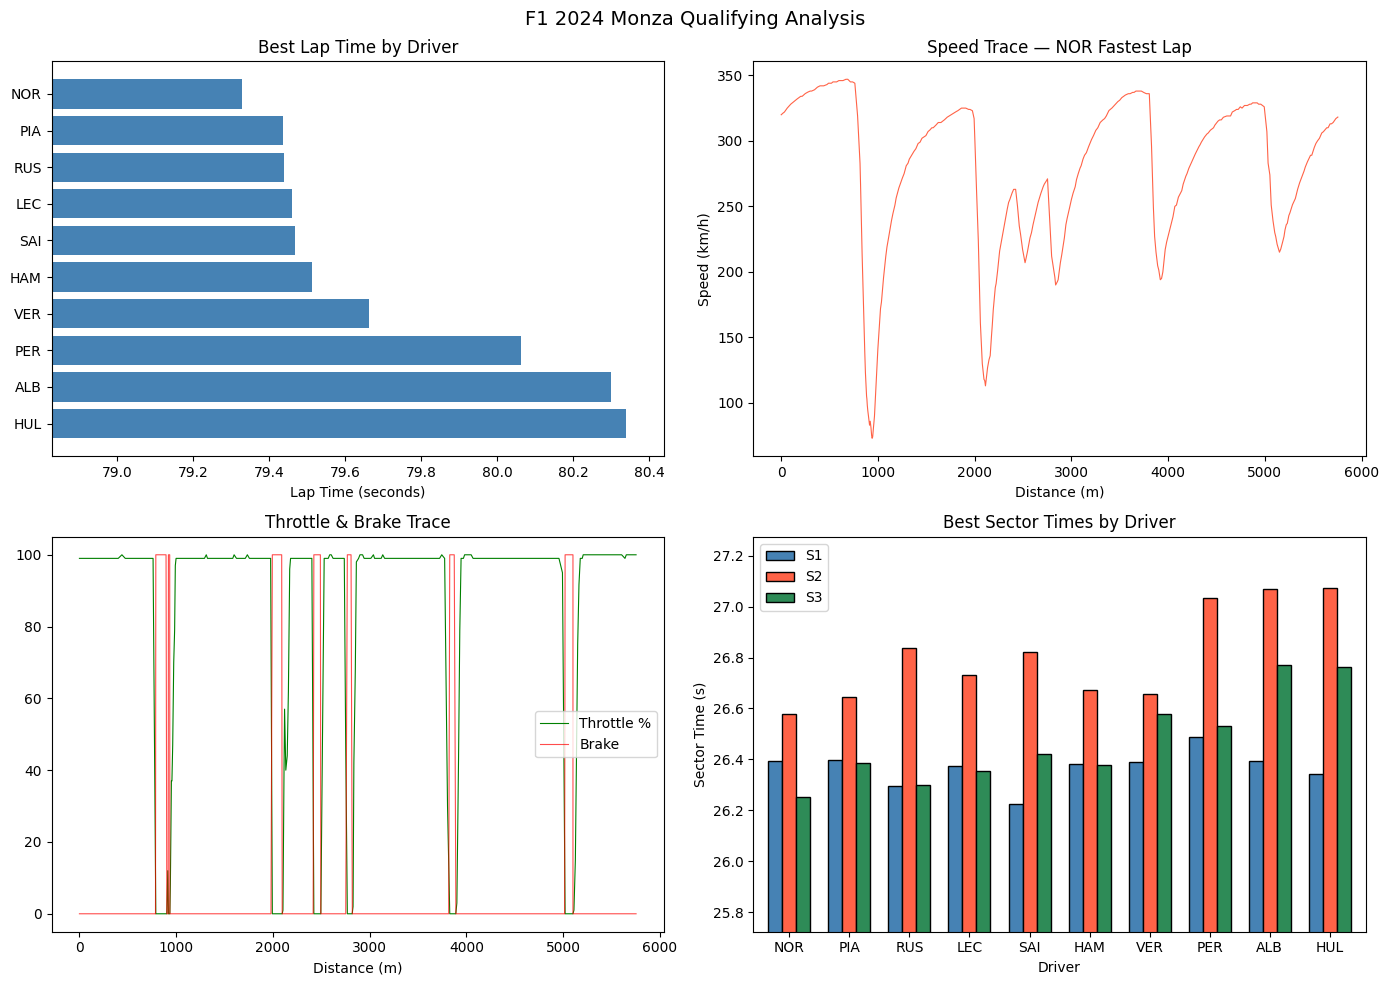

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Top 10 driver lap times
# Get the range of lap times
min_time = top10['LapTimeSeconds'].min()
max_time = top10['LapTimeSeconds'].max()

axes[0,0].barh(top10['Driver'], top10['LapTimeSeconds'], color='steelblue')
axes[0,0].set_title('Best Lap Time by Driver')
axes[0,0].set_xlabel('Lap Time (seconds)')
axes[0,0].invert_yaxis()

# Set x-axis range to just around the actual values
axes[0,0].set_xlim(min_time - 0.5, max_time + 0.1)

# Plot 2: Speed trace of fastest lap
axes[0,1].plot(tel['Distance'], tel['Speed'], color='tomato', linewidth=0.8)
axes[0,1].set_title(f"Speed Trace — {fastest_lap['Driver']} Fastest Lap")
axes[0,1].set_xlabel('Distance (m)')
axes[0,1].set_ylabel('Speed (km/h)')

# Plot 3: Throttle and brake trace
axes[1,0].plot(tel['Distance'], tel['Throttle'], color='green', 
               linewidth=0.8, label='Throttle %')
axes[1,0].plot(tel['Distance'], tel['Brake'].astype(int) * 100, 
               color='red', linewidth=0.8, alpha=0.7, label='Brake')
axes[1,0].set_title('Throttle & Brake Trace')
axes[1,0].set_xlabel('Distance (m)')
axes[1,0].legend()

# Plot 4: Best sector times per driver (top 10)

# Set y-axis range to show differences clearly
min_sector = sector_data.min().min()    # smallest value across all sectors and drivers
max_sector = sector_data.max().max()    # largest value

axes[1,1].set_ylim(min_sector - 0.5, max_sector + 0.2)
top_drivers = best_laps.head(10)['Driver'].tolist()
sector_data = laps[laps['Driver'].isin(top_drivers)].groupby('Driver').agg({
    'S1Seconds': 'min',
    'S2Seconds': 'min', 
    'S3Seconds': 'min'
}).loc[top_drivers]

sector_data.plot(kind='bar', ax=axes[1,1], 
                 color=['steelblue', 'tomato', 'seagreen'],
                 edgecolor='black', width=0.7)
axes[1,1].set_title('Best Sector Times by Driver')
axes[1,1].set_xlabel('Driver')
axes[1,1].set_ylabel('Sector Time (s)')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(['S1', 'S2', 'S3'])

plt.suptitle(f'F1 2024 Monza Qualifying Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('monza_qualifying_analysis.png', dpi=150)
plt.show()

# Monza 2024 Race Analysis

In [42]:
# Load the race session separately
race = fastf1.get_session(2024, 'Monza', 'R')
race.load()

race_laps = race.laps
race_laps['LapTimeSeconds'] = race_laps['LapTime'].dt.total_seconds()

# Clean out safety car laps, pit laps and outliers
race_laps = race_laps.dropna(subset=['LapTimeSeconds'])
race_laps = race_laps[race_laps['LapTimeSeconds'] > 60]
race_laps = race_laps[race_laps['LapTimeSeconds'] < 200]
race_laps = race_laps.reset_index(drop=True)

print("Race laps loaded:", len(race_laps))
print(race_laps[['Driver', 'LapNumber', 'LapTimeSeconds', 
                  'Compound', 'TyreLife', 'PitOutTime', 'PitInTime']].head(10))

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Race laps loaded: 1008
  Driver  LapNumber  LapTimeSeconds Compound  TyreLife PitOutTime PitInTime
0    LEC        1.0          88.179   MEDIUM       1.0        NaT       NaT
1    LEC        2.0          85.396   MEDIUM       2.0        NaT       NaT
2    LEC        3.0          85.179   MEDIUM       3.0        NaT       NaT
3    LEC        4.0          84.810   MEDIUM       4.0        NaT       NaT
4    LEC        5.0          84.603   MEDIUM       5.0        NaT       NaT
5    LEC        6.0          84.663   MEDIUM       6.0        NaT       NaT
6    LEC        7.0          84.434   MEDIUM       7.0        NaT       NaT
7    LEC        8.0          84.569   MEDIUM       8.0        NaT       NaT
8    LEC        9.0          84.362   MEDIUM       9.0        NaT       NaT
9    LEC       10.0          84.432   MEDIUM      10.0        NaT       NaT


## Tyre Strategy - What cost the Mclaren's the win

In [43]:
drivers = ['LEC', 'NOR', 'PIA']
story_laps = race_laps[race_laps['Driver'].isin(drivers)].copy()

# Find pit stops
pit_stops = (story_laps[story_laps['PitInTime'].notna()]
                 .groupby('Driver')[['LapNumber', 'Compound']]
                 .apply(lambda x: x.values.tolist()))

print("=== Pit Stop Summary ===")
for driver, stops in pit_stops.items():
    print(f"\n{driver} — {len(stops)} stop(s):")
    for lap, compound in stops:
        print(f"  Pitted on lap {int(lap)} (was on {compound})")

# Stint lengths per driver
stints = (story_laps.groupby(['Driver', 'Compound', 'Stint'])['LapNumber']
                    .agg(['min', 'max', 'count'])
                    .reset_index())
stints.columns = ['Driver', 'Compound', 'Stint', 'FirstLap', 'LastLap', 'StintLength']

print("\n=== Stint Breakdown ===")
print(stints[stints['Driver'].isin(drivers)].to_string(index=False))

=== Pit Stop Summary ===

LEC — 1 stop(s):
  Pitted on lap 15 (was on MEDIUM)

NOR — 2 stop(s):
  Pitted on lap 14 (was on MEDIUM)
  Pitted on lap 32 (was on HARD)

PIA — 2 stop(s):
  Pitted on lap 16 (was on MEDIUM)
  Pitted on lap 38 (was on HARD)

=== Stint Breakdown ===
Driver Compound  Stint  FirstLap  LastLap  StintLength
   LEC     HARD    2.0      16.0     53.0           38
   LEC   MEDIUM    1.0       1.0     15.0           15
   NOR     HARD    2.0      15.0     32.0           18
   NOR     HARD    3.0      33.0     53.0           21
   NOR   MEDIUM    1.0       1.0     14.0           14
   PIA     HARD    2.0      17.0     38.0           22
   PIA     HARD    3.0      39.0     53.0           15
   PIA   MEDIUM    1.0       1.0     16.0           16


## Lap Time Pace Comparison

- How did lap times evolve across the race for each driver?


In [44]:
pace = (story_laps.groupby(['Driver', 'LapNumber'])['LapTimeSeconds']
                  .mean()
                  .reset_index())

# Rolling average to smooth out traffic/safety car laps
for driver in drivers:
    mask = pace['Driver'] == driver
    pace.loc[mask, 'RollingPace'] = (pace.loc[mask, 'LapTimeSeconds']
                                         .rolling(window=3, center=True)
                                         .mean())

print("=== Average Race Pace ===")
avg_pace = (story_laps.groupby('Driver')['LapTimeSeconds']
                      .mean()
                      .sort_values())
print(avg_pace.round(3))

print("\n=== Best Race Lap ===")
best_race = (story_laps.groupby('Driver')['LapTimeSeconds']
                       .min()
                       .sort_values())
print(best_race.round(3))

=== Average Race Pace ===
Driver
LEC    84.542
PIA    84.592
NOR    84.658
Name: LapTimeSeconds, dtype: float64

=== Best Race Lap ===
Driver
NOR    81.432
PIA    81.943
LEC    83.226
Name: LapTimeSeconds, dtype: float64


## Tyre Degradation Per Stint

- How did tyre age affect lap time for each driver?
- This is the key question — did the McLarens degrade faster?

In [45]:
degradation = (story_laps.groupby(['Driver', 'Compound', 'TyreLife'])['LapTimeSeconds']
                          .mean()
                          .reset_index())

print("=== Lap Time vs Tyre Age ===")
for driver in drivers:
    d = degradation[degradation['Driver'] == driver]
    print(f"\n{driver}:")
    print(d[['Compound', 'TyreLife', 'LapTimeSeconds']].to_string(index=False))

=== Lap Time vs Tyre Age ===

LEC:
Compound  TyreLife  LapTimeSeconds
    HARD       1.0         104.888
    HARD       2.0          84.270
    HARD       3.0          83.875
    HARD       4.0          84.203
    HARD       5.0          83.826
    HARD       6.0          83.880
    HARD       7.0          83.768
    HARD       8.0          83.864
    HARD       9.0          83.640
    HARD      10.0          83.590
    HARD      11.0          83.321
    HARD      12.0          83.534
    HARD      13.0          83.284
    HARD      14.0          83.229
    HARD      15.0          83.359
    HARD      16.0          83.972
    HARD      17.0          83.274
    HARD      18.0          83.226
    HARD      19.0          83.430
    HARD      20.0          83.681
    HARD      21.0          83.714
    HARD      22.0          83.550
    HARD      23.0          83.624
    HARD      24.0          83.718
    HARD      25.0          83.690
    HARD      26.0          83.611
    HARD      27.0  

##  The Strategy Verdict

- Gap analysis: where did LEC gain time on NOR and PIA?

In [46]:
lec_laps = story_laps[story_laps['Driver'] == 'LEC'][['LapNumber', 'LapTimeSeconds']].set_index('LapNumber')
nor_laps = story_laps[story_laps['Driver'] == 'NOR'][['LapNumber', 'LapTimeSeconds']].set_index('LapNumber')
pia_laps = story_laps[story_laps['Driver'] == 'PIA'][['LapNumber', 'LapTimeSeconds']].set_index('LapNumber')

# Align on common laps
common_laps = lec_laps.index.intersection(nor_laps.index)

gap_lec_nor = (nor_laps.loc[common_laps, 'LapTimeSeconds'] - 
               lec_laps.loc[common_laps, 'LapTimeSeconds']).cumsum()

print("=== Cumulative Time Gap: LEC vs NOR ===")
print("Positive = LEC ahead, Negative = NOR ahead")
print(gap_lec_nor.tail(10).round(3))

# Total pit stop time lost
print("\n=== Strategy Cost ===")
print("LEC: 1 stop  — 1 x ~22s pit stop time lost")
print("NOR: 2 stops — 2 x ~22s pit stop time lost (~44s total)")
print("PIA: 2 stops — 2 x ~22s pit stop time lost (~44s total)")

lec_time = race.results[race.results['Abbreviation'] == 'LEC']['Time'].values[0]
readable = pd.Timedelta(lec_time)

total_seconds = readable.total_seconds()
minutes = int(total_seconds // 60)
seconds = total_seconds % 60

print(f"\nLEC won by: {minutes}m {seconds:.3f}s")

=== Cumulative Time Gap: LEC vs NOR ===
Positive = LEC ahead, Negative = NOR ahead
LapNumber
44.0    16.356
45.0    15.023
46.0    13.467
47.0    13.643
48.0    11.949
49.0    10.918
50.0    10.723
51.0     9.437
52.0     7.989
53.0     6.153
Name: LapTimeSeconds, dtype: float64

=== Strategy Cost ===
LEC: 1 stop  — 1 x ~22s pit stop time lost
NOR: 2 stops — 2 x ~22s pit stop time lost (~44s total)
PIA: 2 stops — 2 x ~22s pit stop time lost (~44s total)

LEC won by: 74m 40.727s


## Race Visualization

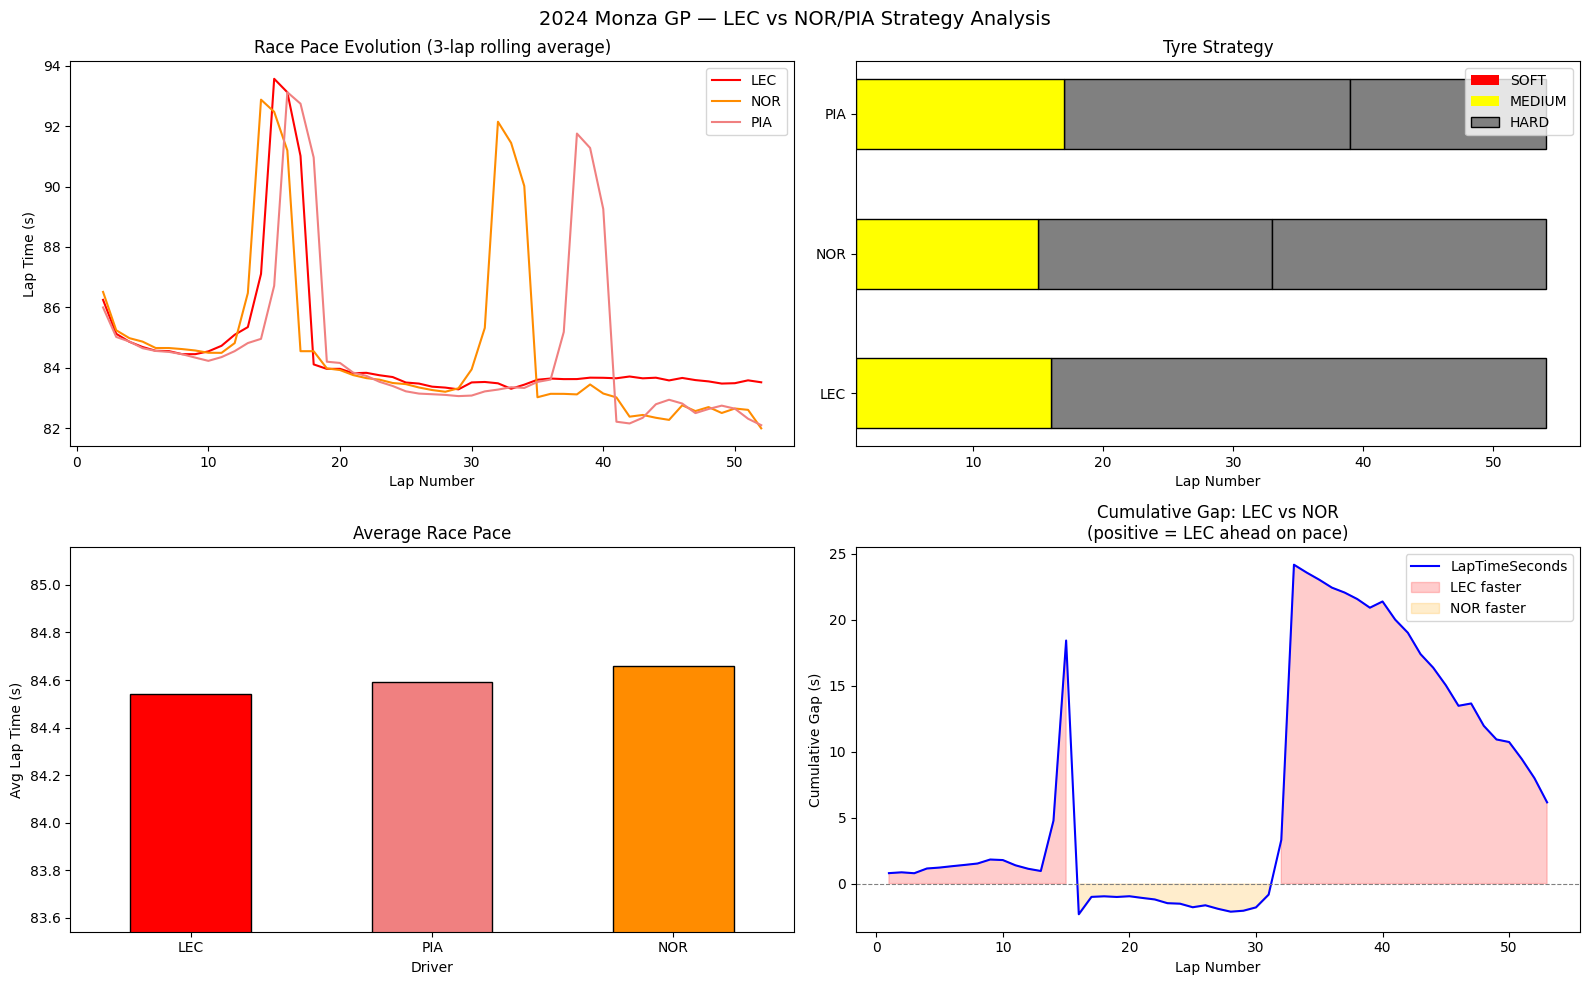

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {'LEC': 'red', 'NOR': 'darkorange', 'PIA': 'lightcoral'}

# Plot 1 — Lap time evolution
for driver in drivers:
    d = pace[pace['Driver'] == driver]
    axes[0,0].plot(d['LapNumber'], d['RollingPace'], 
                   color=colors[driver], linewidth=1.5, label=driver)
axes[0,0].set_title('Race Pace Evolution (3-lap rolling average)')
axes[0,0].set_xlabel('Lap Number')
axes[0,0].set_ylabel('Lap Time (s)')
axes[0,0].legend()

# Plot 2 — Stint strategy visualisation
for i, driver in enumerate(drivers):
    d = story_laps[story_laps['Driver'] == driver]
    compound_colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'grey'}
    for _, stint_row in stints[stints['Driver'] == driver].iterrows():
        color = compound_colors.get(stint_row['Compound'], 'grey')
        axes[0,1].barh(driver, 
                       stint_row['StintLength'],
                       left=stint_row['FirstLap'],
                       color=color, edgecolor='black', height=0.5)

axes[0,1].set_title('Tyre Strategy')
axes[0,1].set_xlabel('Lap Number')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='SOFT'),
                   Patch(facecolor='yellow', label='MEDIUM'),
                   Patch(facecolor='grey', edgecolor='black', label='HARD')]
axes[0,1].legend(handles=legend_elements)

# Plot 3 — Average pace comparison
avg_pace.plot(kind='bar', ax=axes[1,0], 
              color=[colors[d] for d in avg_pace.index],
              edgecolor='black')
axes[1,0].set_title('Average Race Pace')
axes[1,0].set_ylabel('Avg Lap Time (s)')
axes[1,0].tick_params(axis='x', rotation=0)
min_pace = avg_pace.min()
axes[1,0].set_ylim(min_pace - 1, avg_pace.max() + 0.5)

# Plot 4 — Cumulative gap LEC vs NOR
gap_lec_nor.plot(ax=axes[1,1], color='blue', linewidth=1.5)
axes[1,1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1,1].set_title('Cumulative Gap: LEC vs NOR\n(positive = LEC ahead on pace)')
axes[1,1].set_xlabel('Lap Number')
axes[1,1].set_ylabel('Cumulative Gap (s)')
axes[1,1].fill_between(gap_lec_nor.index, gap_lec_nor.values, 0,
                        where=gap_lec_nor.values > 0,
                        alpha=0.2, color='red', label='LEC faster')
axes[1,1].fill_between(gap_lec_nor.index, gap_lec_nor.values, 0,
                        where=gap_lec_nor.values < 0,
                        alpha=0.2, color='orange', label='NOR faster')
axes[1,1].legend()

plt.suptitle('2024 Monza GP — LEC vs NOR/PIA Strategy Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('monza_race_analysis.png', dpi=150)
plt.show()